# Part 2b — Benders, and what decomposition actually buys

### It is slower. That is not the point.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/advopt-lithiumsc/blob/main/notebooks/02b_benders.ipynb)

Part 2 hit a wall: the extensive form replicates the whole model once per
scenario, so it stops fitting. Progressive hedging was one way around it. This is
the other, and it is the one with a **bound** attached rather than a heuristic.

### The idea in one line

Solve a **master** holding only the first-stage decisions plus a placeholder for
what the second stage will cost. Whenever the placeholder is optimistic, add a
constraint that says so, built from the subproblem's duals.

$$\theta_k \;\ge\; Q_k(\hat c) \;+\; \beta_k^\top (c - \hat c)$$

$Q_k$ is convex in the capacity right-hand side, so that line is **exact at
$\hat c$ and an underestimate everywhere else** — it can never cut off the true
optimum. The master is therefore a relaxation, its objective is a valid lower
bound, and evaluating the real recourse at any proposed plan gives a valid upper
bound. The two meet.

### Read this before you expect a speed-up

| at n = 200 | extensive form | L-shaped, single cut | L-shaped, multicut |
|---|---|---|---|
| variables in the biggest model solved | **4,012** | master **13**, subproblem 20 | master 212, subproblem 20 |
| constraints added by cuts | — | 22, one per iteration | ~3,000, one per scenario per iteration |
| fits the restricted licence? | **no** | **yes** | **no** |
| wall time | **faster** | slower, at every size tested | slower |

**The third column is the one worth pausing on.** Multicut is the better variant
on iterations and it is the one that fails here — because the restricted licence
caps *constraints* as well as variables, and multicut buys its faster convergence
by adding a cut per scenario per iteration. Decomposition escapes the variable
limit; it does not automatically escape every limit.

**Decomposition loses on time here and wins on size.** Section 10 measures both
rather than asserting them. Gurobi is extremely good at the monolithic model at
this scale; the reason to learn this method is that the monolithic model is the
thing that stops existing.

Note what is quoted above and what is not. Variable counts are a property of the
formulation and will be identical on your machine. **Wall times are not**, so
none appear in this notebook's prose — section 10's table prints the timings from
*your* run, and they will not match mine. A tutorial that hard-codes "1.4x
faster" is wrong for most of its readers within a year.

### Why a new, smaller instance

The second stage has to be a **linear** program for the duals in that cut to
exist. Part 1's model buries capacity under binaries, vintages and lead times,
and there is no clean dual to build a cut from. Section 2 says more.

## 0. Setup

One cell, and it is the only place the `lithium` package appears before the final check. On Colab it
clones the repo and installs it; locally it assumes you have already run `pip install -e .` and just
moves up out of `notebooks/` so the relative data paths work.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/advopt-lithiumsc.git"
# Forked or renamed? Change BOTH halves of that path. Only the owner ever
# looked like a placeholder, and the repo name beside it broke 64 URLs once.
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if "google.colab" in sys.modules:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_NAME)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif Path.cwd().name == "notebooks":
    os.chdir("..")

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})
print(f"working directory : {Path.cwd().name}")
print(f"gurobipy          : {gp.gurobi.version()}")
print(f"pandas            : {pd.__version__}")

working directory : Advanced Opt Modeling Examples
gurobipy          : (13, 0, 2)
pandas            : 2.3.3


## 2. The instance

**This is a third instance, and confusing it with the other two will waste an
hour.** Part 1 and Part 2 use a six-site, twenty-year network with vintages,
lead times and learning. Part 4 uses a two-region chain owned by competing
firms. This one is single-period: three stages, two regions, six capacity
nodes, twelve arcs, and no time at all.

It is smaller on purpose. Part 2b needs the **duals** of the capacity rows, and
for those to exist the second stage has to be a linear program. In Part 1's
model capacity is entangled with binaries, vintages and lead times, and there is
no clean dual to build a cut from.

| file | keyed by | rows |
|---|---|---|
| `twostage_stages.csv` | `stage` | 3 |
| `twostage_regions.csv` | `region` | 2 |

`region_cost` is read by both notebooks and used only by Part 2c; Part 2b has no
regional cost asymmetry. They are different models, not one model with a flag.

Read the two tables and look at them as frames before turning them into anything
the model indexes.

In [2]:
DATA = Path("data/raw")

if not (DATA / "twostage_stages.csv").exists():
    print("!" * 78)
    print("! data/raw/ was not found, so this notebook is FALLING BACK to generated")
    print("! numbers. Everything below will run and every figure will render, but the")
    print("! results are NOT the shipped instance and are NOT an acceptable submission.")
    print("! Fix: clone the repo (see section 0) or run this notebook from the repo root.")
    print("!" * 78)
    DATA = Path("_generated_fallback")
    DATA.mkdir(exist_ok=True)
    (DATA / "twostage_stages.csv").write_text(
        "stage,fix,unit,opc,eta\nMINE,240.0,2.2,0.8,0.95\n"
        "PROC,200.0,2.9,1.3,0.90\nMFG,160.0,3.3,1.6,0.93\n")
    (DATA / "twostage_regions.csv").write_text(
        "region,demand_base,region_cost\nR1,34.0,0.72\nR2,22.0,1.00\n")

stages_df = pd.read_csv(DATA / "twostage_stages.csv")
regions_df = pd.read_csv(DATA / "twostage_regions.csv")
print(f"twostage_stages.csv : {len(stages_df)} rows x {len(stages_df.columns)} columns")
print(f"twostage_regions.csv: {len(regions_df)} rows x {len(regions_df.columns)} columns")
stages_df

twostage_stages.csv : 3 rows x 5 columns
twostage_regions.csv: 2 rows x 3 columns


,stage,fix,unit,opc,eta
0,MINE,240.0,2.2,0.8,0.95
1,PROC,200.0,2.9,1.3,0.90
2,MFG,160.0,3.3,1.6,0.93


A frame shows rows and columns. The model does not index by row number — it
indexes by `stage` and by `region`. Print the dictionary form so the **key** is
explicit rather than implied by the layout.

In [3]:
STAGES = tuple(stages_df["stage"])
REGIONS = tuple(regions_df["region"])

FIX = dict(zip(stages_df["stage"], stages_df["fix"].astype(float)))
UNIT = dict(zip(stages_df["stage"], stages_df["unit"].astype(float)))
OPC = dict(zip(stages_df["stage"], stages_df["opc"].astype(float)))
ETA = dict(zip(stages_df["stage"], stages_df["eta"].astype(float)))
DEMAND_BASE = dict(zip(regions_df["region"], regions_df["demand_base"].astype(float)))
REGION_COST = dict(zip(regions_df["region"], regions_df["region_cost"].astype(float)))

print(f"STAGES  {STAGES}")
print(f"REGIONS {REGIONS}")
for name, d in (("FIX", FIX), ("UNIT", UNIT), ("OPC", OPC), ("ETA", ETA)):
    print(f"{name:12s} {d}")
print(f"{'DEMAND_BASE':12s} {DEMAND_BASE}")
print(f"{'REGION_COST':12s} {REGION_COST}   (Part 2c only)")

# Try it: give R2 the cheaper operating costs instead and watch section 11
# stay green, because the package is handed this table rather than re-reading it.
# REGION_COST["R1"], REGION_COST["R2"] = 1.00, 0.72

STAGES  ('MINE', 'PROC', 'MFG')
REGIONS ('R1', 'R2')
FIX          {'MINE': 240.0, 'PROC': 200.0, 'MFG': 160.0}
UNIT         {'MINE': 2.2, 'PROC': 2.9, 'MFG': 3.3}
OPC          {'MINE': 0.8, 'PROC': 1.3, 'MFG': 1.6}
ETA          {'MINE': 0.95, 'PROC': 0.9, 'MFG': 0.93}
DEMAND_BASE  {'R1': 34.0, 'R2': 22.0}
REGION_COST  {'R1': 0.72, 'R2': 1.0}   (Part 2c only)


## 3. The knobs, and the sets derived from them

Everything in this section is either a **knob** — a scalar carrying a concept,
written out here where the sentence explaining it is — or **arithmetic** on the
tables above. Nothing here is data.

The four knobs:

- `CMIN`, `CMAX` — a node that opens at all must be at least `CMIN` and at most
  `CMAX`. Together with the binary `y` this is what makes stage 1 a *discrete*
  decision rather than a continuous one, and therefore what makes the master
  problem in Part 2b a MILP.
- `PEN` — the penalty per unit of unmet demand. It has to exceed the cost of
  serving that demand the expensive way, or the model will simply decline to
  serve it.
- `TAU_OWN`, `TAU_CROSS` — transport within a region and across regions.

In [4]:
CMIN, CMAX = 5.0, 70.0        # a node that opens is between these
PEN = 30.0                    # per unit of unmet demand
TAU_OWN, TAU_CROSS = 0.3, 1.5   # transport within / across regions

NODES = [(s, r) for s in STAGES for r in REGIONS]
ARCS = [(s, a, b) for s in STAGES for a in REGIONS for b in REGIONS]
TAU = {(a, b): (TAU_OWN if a == b else TAU_CROSS)
       for a in REGIONS for b in REGIONS}

print(f"{len(NODES)} capacity nodes, {len(ARCS)} arcs")
print(f"nodes: {NODES}")
print(f"TAU  : {TAU}")
print(f"\ncrossing a region costs {TAU_CROSS / TAU_OWN:.0f}x what staying home does,")
print(f"and PEN = {PEN} is {PEN / max(OPC.values()):.0f}x the dearest stage's opex,")
print("so unmet demand is a last resort rather than a cheap way out.")

6 capacity nodes, 12 arcs
nodes: [('MINE', 'R1'), ('MINE', 'R2'), ('PROC', 'R1'), ('PROC', 'R2'), ('MFG', 'R1'), ('MFG', 'R2')]
TAU  : {('R1', 'R1'): 0.3, ('R1', 'R2'): 1.5, ('R2', 'R1'): 1.5, ('R2', 'R2'): 0.3}

crossing a region costs 5x what staying home does,
and PEN = 30.0 is 19x the dearest stage's opex,
so unmet demand is a last resort rather than a cheap way out.


### 3.1 What a plan can physically deliver

Yields compound down the chain, so a MINE node of capacity $c$ can support at
most $\eta_{\text{MINE}} c$ of processing and $\eta_{\text{MINE}}
\eta_{\text{PROC}} c$ of manufacturing. That product is worth computing now,
because it turns up as the answer later: the optimal plans in both notebooks sit
exactly on this chain rather than anywhere in between.

In [5]:
chain = 1.0
for s in STAGES:
    chain *= ETA[s]
    print(f"a unit of MINE capacity supports {chain:.4f} through {s}")

MAX_DELIVERABLE = CMAX * ETA[STAGES[0]] * ETA[STAGES[1]]
print(f"\none full-size chain ({CMAX:.0f} at each stage, sized down the yields):")
print(f"  {CMAX:.2f} -> {CMAX * ETA[STAGES[0]]:.2f} -> {MAX_DELIVERABLE:.4f}")
print(f"total peak demand across regions can reach "
      f"{sum(DEMAND_BASE.values()) * 1.55:.1f}, so one chain is not obviously enough")

a unit of MINE capacity supports 0.9500 through MINE
a unit of MINE capacity supports 0.8550 through PROC
a unit of MINE capacity supports 0.7952 through MFG

one full-size chain (70 at each stage, sized down the yields):
  70.00 -> 66.50 -> 59.8500
total peak demand across regions can reach 86.8, so one chain is not obviously enough


## 4. The scenario tree

Demand only, uniform on $[0.55, 1.55]$ times each region's base. Twenty-four
equally likely draws.

**The draw order is part of the definition, not an implementation detail.** One
call to the generator per region per scenario, regions in table order. Reorder
those two lines and you get a different tree from the same seed — which is
exactly the kind of thing that makes a result irreproducible for a reader on a
different machine. The seed is set and printed for the same reason.

In [6]:
import random

SEED, NK = 11, 24
LO, HI = 0.55, 1.55

rng = random.Random(SEED)
SCEN = []
for k in range(NK):
    d = {}
    for r in REGIONS:                       # region order is part of the tree
        d[r] = DEMAND_BASE[r] * (LO + (HI - LO) * rng.random())
    SCEN.append((f"k{k}", 1.0 / NK, d))

assert abs(sum(p for _, p, _ in SCEN) - 1.0) < 1e-12, "probabilities must sum to 1"
print(f"seed {SEED}, {NK} equally likely scenarios (p = {1 / NK:.4f})")
for r in REGIONS:
    lo = min(s[2][r] for s in SCEN)
    hi = max(s[2][r] for s in SCEN)
    print(f"  {r}: demand {lo:6.1f} to {hi:6.1f}   (base {DEMAND_BASE[r]:.1f})")
print(f"\npeak total demand {max(sum(s[2].values()) for s in SCEN):.1f} "
      f"against one full chain's {MAX_DELIVERABLE:.2f}")

seed 11, 24 equally likely scenarios (p = 0.0417)
  R1: demand   19.7 to   52.6   (base 34.0)
  R2: demand   12.4 to   34.0   (base 22.0)

peak total demand 86.6 against one full chain's 59.85


## 5. The extensive form — the answer that must be reproduced

Everything in one model: one copy of the first stage, twenty-four copies of the
second. This is what decomposition has to match, and it is worth solving first
precisely so that the L-shaped loop has something to be checked against.

**The first stage is the same variables no matter which scenario happens** —
that is the nonanticipativity of Part 2, expressed here by simply not
subscripting `y` and `c` by `k`.

> **Predict before you run.** Two regions, and R1's demand base is 34 against
> R2's 22. Will the optimal plan open nodes in both regions, or concentrate?

In [7]:
import gurobipy as gp
from gurobipy import GRB
import time

MIPGAP = 1e-9    # far tighter than anything compared below; see section 11


# THE FUNCTION IS THE LESSON: the whole method rests on the extensive form and
# the standalone recourse LP being the SAME second stage. Writing the block out
# twice would let them drift, and a Benders loop whose subproblem differs from
# the model it is meant to reproduce converges neatly to the wrong answer.
def second_stage(m, cap, scen, suffix):
    """One scenario's recourse block. `cap` may be Gurobi vars OR fixed floats.

    Building it the same way in both cases is what makes the monolithic model
    and the standalone recourse LP the same model rather than two similar ones.
    """
    x = m.addVars(NODES, lb=0.0, name=f"x{suffix}")
    f = m.addVars(ARCS, lb=0.0, name=f"f{suffix}")
    u = m.addVars(REGIONS, lb=0.0, name=f"u{suffix}")
    link = m.addConstrs((x[n] <= cap[n] for n in NODES), name=f"cap{suffix}")
    m.addConstrs((ETA[s] * x[s, r] == f.sum(s, r, "*") for (s, r) in NODES),
                 name=f"out{suffix}")
    for i, s in enumerate(STAGES):
        if i == 0:
            continue
        prev = STAGES[i - 1]
        m.addConstrs((f.sum(prev, "*", r) == x[s, r] for r in REGIONS),
                     name=f"in_{s}{suffix}")
    m.addConstrs((f.sum(STAGES[-1], "*", r) + u[r] >= scen[2][r] for r in REGIONS),
                 name=f"dem{suffix}")
    cost = (gp.quicksum(OPC[s] * x[s, r] for (s, r) in NODES)
            + gp.quicksum(TAU[a, b] * f[s, a, b] for (s, a, b) in ARCS)
            + gp.quicksum(PEN * u[r] for r in REGIONS))
    return cost, link

Now the first stage and the monolithic model. `y` is the open/closed decision and
`c` the size; the two `CMIN`/`CMAX` rows are what tie them together, and they are
the reason the master in section 7 is a MILP rather than an LP.

In [8]:
ef = gp.Model("extensive_form")
ef.Params.OutputFlag = 0
ef.Params.MIPGap = MIPGAP

y = ef.addVars(NODES, vtype=GRB.BINARY, name="y")
c = ef.addVars(NODES, lb=0.0, ub=CMAX, name="c")
ef.addConstrs((c[n] <= CMAX * y[n] for n in NODES), name="ub")
ef.addConstrs((c[n] >= CMIN * y[n] for n in NODES), name="lb")
first = gp.quicksum(FIX[s] * y[s, r] + UNIT[s] * c[s, r] for (s, r) in NODES)

second = gp.LinExpr()
for j, scen in enumerate(SCEN):
    cost_j, _ = second_stage(ef, c, scen, f"_{j}")
    second += scen[1] * cost_j

ef.setObjective(first + second, GRB.MINIMIZE)
t0 = time.time()
ef.optimize()
T_EF = time.time() - t0

assert ef.SolCount > 0, f"the extensive form found no solution (status {ef.Status})"
assert ef.NumVars > 0 and ef.NumConstrs > 0, "an empty model reports success too"
EF_VAL = ef.ObjVal
CAP_EF = {n: c[n].X for n in NODES}
print(f"extensive form: {EF_VAL:.6f}   ({T_EF:.2f}s, {ef.NumVars} variables, "
      f"{ef.NumConstrs} constraints, {ef.NumBinVars} binaries)")
for (s, r) in NODES:
    if CAP_EF[s, r] > 1e-6:
        print(f"  open {s}/{r}: {CAP_EF[s, r]:.2f}")

Restricted license - for non-production use only - expires 2027-11-29


extensive form: 1651.194488   (0.01s, 492 variables, 444 constraints, 6 binaries)
  open MINE/R1: 70.00
  open PROC/R1: 66.50
  open MFG/R1: 59.85


**It concentrates everything in R1** and opens nothing in R2. R1 has the larger
demand base, and crossing a region costs five times what staying home does, so
one chain sited where the demand is beats two half-sized ones.

Look at the three capacities: 70.00, 66.50, 59.85. Those are not independent
numbers — they are `CMAX` walked down the yield chain, $70 \times 0.95 = 66.5$
and $66.5 \times 0.90 = 59.85$. The plan builds one maximal chain and sizes each
stage to exactly what the stage above can feed it. Building any more would be
capacity that can never be used.

That is a **structural** property, not an artefact of these numbers, so it is
worth asserting rather than admiring.

In [9]:
mine = CAP_EF["MINE", "R1"]
expect = {"MINE": mine,
          "PROC": mine * ETA["MINE"],
          "MFG": mine * ETA["MINE"] * ETA["PROC"]}
for s in STAGES:
    got = CAP_EF[s, "R1"]
    print(f"  {s:5s} built {got:8.4f}   yield chain says {expect[s]:8.4f}")
    assert abs(got - expect[s]) < 1e-6, (
        f"{s} capacity is off the yield chain; either the plan is not maximal "
        f"or the flow-balance rows are wrong")
assert all(CAP_EF[s, "R2"] < 1e-6 for s in STAGES), "R2 was expected to stay shut"
print("\nevery stage sits exactly on the yield chain, and R2 stays shut")

  MINE  built  70.0000   yield chain says  70.0000
  PROC  built  66.5000   yield chain says  66.5000
  MFG   built  59.8500   yield chain says  59.8500

every stage sits exactly on the yield chain, and R2 stays shut


## 6. The recourse LP, and where a cut comes from

Fix the capacities to numbers and one scenario's problem becomes a plain LP.
Solve it and you get two things: its cost $Q_k(\hat c)$, and — the part that
matters — the **duals of the capacity rows**.

$$\beta_{k,n} \;=\; \frac{\partial Q_k}{\partial c_n}$$

A dual on `x[n] <= c[n]` says exactly how much scenario $k$'s cost would fall if
node $n$ had one more unit of capacity. That is a subgradient of $Q_k$, and a
subgradient is all a cut needs.

**This is the line that makes the method work**, and it is why the second stage
had to be an LP: `link[n].Pi`.

In [10]:
# THE FUNCTION IS THE LESSON: this is the subproblem the method is built on,
# and sections 7, 10 and 11 call it several hundred times at different plans.
def recourse(cap, scen, duals=True):
    """Q_k(cap) for one scenario, plus the capacity duals that become the cut."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    cost, link = second_stage(m, cap, scen, "")
    m.setObjective(cost, GRB.MINIMIZE)
    m.optimize()
    assert m.Status == GRB.OPTIMAL, (
        f"recourse for {scen[0]} is not optimal (status {m.Status}); a cut "
        f"built from a non-optimal subproblem is not valid")
    beta = {n: link[n].Pi for n in NODES} if duals else None
    return m.ObjVal, beta


zero_cap = {n: 0.0 for n in NODES}
q0, b0 = recourse(zero_cap, SCEN[0])
print(f"scenario {SCEN[0][0]} with NO capacity: cost {q0:.4f}")
print("  (all demand unmet, so this is just the penalty)")
print(f"  check: PEN x total demand = "
      f"{PEN * sum(SCEN[0][2].values()):.4f}")
print("\n  duals - what one more unit of each node would save:")
for n in NODES:
    print(f"    {n[0]:5s}/{n[1]}  {b0[n]:9.4f}")

scenario k0 with NO capacity: cost 1754.8769
  (all demand unmet, so this is just the penalty)
  check: PEN x total demand = 1754.8769

  duals - what one more unit of each node would save:
    MINE /R1     0.0000
    MINE /R2     0.0000
    PROC /R1     0.0000
    PROC /R2     0.0000
    MFG  /R1   -26.0210
    MFG  /R2   -26.0210


Every dual is negative or zero: more capacity never costs more. The MINE duals
are the largest in magnitude because a mine feeds the whole chain — one unit
there unlocks $0.95 \times 0.90 = 0.855$ units of finished product.

> **Predict before you run.** The loop below starts from zero capacity, where
> every scenario is desperate for more. Will the lower bound rise smoothly, or
> jump?

## 7. The L-shaped loop, built by hand

The master holds `y`, `c`, and one $\theta_k$ per scenario. `lb=0` on $\theta$ is
valid here because every second-stage cost coefficient is non-negative, so the
recourse cost can never be negative — a bound that costs nothing and saves the
first iteration from being unbounded.

Each pass:

1. Solve the master. It is a relaxation, so its objective is a **lower bound**.
2. Evaluate the true recourse at the plan it proposed. First-stage cost plus the
   expected true recourse is a **feasible** plan's cost, hence an **upper bound**.
3. For every scenario whose $\theta_k$ was optimistic, add the cut.
4. Stop when nothing was optimistic, or the bounds meet.

**Adding a cut per scenario is the "multicut" variant.** Section 9 compares it
against aggregating them into one.

In [11]:
# THE FUNCTION IS THE LESSON: an iterative algorithm cannot be written out
# inline, and sections 8 to 10 call it at four scenario counts and both cut
# styles. Every line is narrated above; nothing here is hidden convenience.
def lshaped(scens, max_iter=60, tol=1e-6, multicut=True, verbose=True):
    m = gp.Model("master")
    m.Params.OutputFlag = 0
    m.Params.MIPGap = MIPGAP
    yv = m.addVars(NODES, vtype=GRB.BINARY, name="y")
    cv = m.addVars(NODES, lb=0.0, ub=CMAX, name="c")
    m.addConstrs((cv[n] <= CMAX * yv[n] for n in NODES))
    m.addConstrs((cv[n] >= CMIN * yv[n] for n in NODES))
    fc_expr = gp.quicksum(FIX[s] * yv[s, r] + UNIT[s] * cv[s, r]
                          for (s, r) in NODES)

    if multicut:
        th = m.addVars(range(len(scens)), lb=0.0, name="theta")
        m.setObjective(fc_expr + gp.quicksum(scens[j][1] * th[j]
                                             for j in range(len(scens))),
                       GRB.MINIMIZE)
    else:
        th1 = m.addVar(lb=0.0, name="theta")
        m.setObjective(fc_expr + th1, GRB.MINIMIZE)

    hist, UB, best, subsolves = [], float("inf"), None, 0
    for it in range(1, max_iter + 1):
        m.optimize()
        assert m.SolCount > 0, f"master infeasible at iteration {it}"
        LB = m.ObjVal                          # a relaxation -> valid lower bound
        chat = {n: cv[n].X for n in NODES}
        fc = sum(FIX[s] * yv[s, r].X + UNIT[s] * cv[s, r].X for (s, r) in NODES)

        total, ncuts = fc, 0
        if multicut:
            for j, scen in enumerate(scens):
                Qj, beta = recourse(chat, scen)
                subsolves += 1
                total += scen[1] * Qj
                if th[j].X < Qj - tol * max(1.0, abs(Qj)):
                    m.addConstr(th[j] >= Qj + gp.quicksum(
                        beta[n] * (cv[n] - chat[n]) for n in NODES))
                    ncuts += 1
        else:
            Qbar, bbar = 0.0, {n: 0.0 for n in NODES}
            for scen in scens:
                Qj, beta = recourse(chat, scen)
                subsolves += 1
                Qbar += scen[1] * Qj
                for n in NODES:
                    bbar[n] += scen[1] * beta[n]
            total += Qbar
            if th1.X < Qbar - tol * max(1.0, abs(Qbar)):
                m.addConstr(th1 >= Qbar + gp.quicksum(
                    bbar[n] * (cv[n] - chat[n]) for n in NODES))
                ncuts += 1

        if total < UB:
            UB, best = total, dict(chat)
        gap = (UB - LB) / max(1e-9, abs(UB))
        hist.append(dict(iter=it, LB=LB, UB=UB, gap=gap, cuts=ncuts))
        if verbose and (it <= 3 or it % 5 == 0 or ncuts == 0):
            print(f"  it {it:3d}  LB {LB:10.3f}  UB {UB:10.3f}  "
                  f"gap {100 * gap:8.4f}%  cuts {ncuts}")
        if ncuts == 0 or gap < 1e-6:
            break
    return dict(value=UB, bound=hist[-1]["LB"], iters=len(hist), hist=hist,
                plan=best, subsolves=subsolves, master=m)


t0 = time.time()
LS = lshaped(SCEN)
T_LS = time.time() - t0
print(f"\nL-shaped: {LS['value']:.6f}   ({T_LS:.2f}s, {LS['iters']} iterations, "
      f"{LS['subsolves']} subproblem solves)")

  it   1  LB      0.000  UB   1758.173  gap 100.0000%  cuts 24
  it   2  LB    529.817  UB   1758.173  gap  69.8655%  cuts 24


  it   3  LB    529.817  UB   1758.173  gap  69.8655%  cuts 24


  it   5  LB   1059.347  UB   1758.173  gap  39.7473%  cuts 24


  it  10  LB   1524.509  UB   1713.225  gap  11.0153%  cuts 24


  it  15  LB   1651.194  UB   1651.194  gap   0.0000%  cuts 0

L-shaped: 1651.194488   (0.58s, 15 iterations, 360 subproblem solves)


## 8. It must reproduce the extensive form

Not "come close". The cuts are valid and exact at the point they were generated,
so at convergence the two are the *same optimisation problem* and the objectives
must agree to solver tolerance.

The bounds are worth asserting too: the master's final objective is a lower bound
and the evaluated plan is an upper bound, so the true optimum is between them by
construction. If it were not, a cut would have removed the optimum.

In [12]:
rel = abs(LS["value"] - EF_VAL) / abs(EF_VAL)
print(f"extensive form : {EF_VAL:.9f}")
print(f"L-shaped       : {LS['value']:.9f}")
print(f"relative diff  : {rel:.3e}")
assert rel < 1e-9, f"L-shaped did not reproduce the extensive form ({rel:.2e})"

assert LS["bound"] <= EF_VAL + 1e-6, (
    "the final lower bound exceeds the true optimum, so a cut removed it")
assert LS["value"] >= EF_VAL - 1e-9, "a feasible plan beat the optimum"
print("\nbounds bracket the optimum: "
      f"{LS['bound']:.6f} <= {EF_VAL:.6f} <= {LS['value']:.6f}")

cmp_plan = pd.DataFrame([
    {"node": f"{s}/{r}", "extensive form": round(CAP_EF[s, r], 4),
     "L-shaped": round(LS["plan"][s, r], 4)} for (s, r) in NODES])
print()
cmp_plan

extensive form : 1651.194488294
L-shaped       : 1651.194488294
relative diff  : 1.377e-16

bounds bracket the optimum: 1651.194488 <= 1651.194488 <= 1651.194488



,node,extensive form,L-shaped
0,MINE/R1,70.00,70.00
1,MINE/R2,0.00,0.00
2,PROC/R1,66.50,66.50
3,PROC/R2,0.00,0.00
4,MFG/R1,59.85,59.85
5,MFG/R2,0.00,0.00


The plans match here as well, but that is a courtesy rather than a guarantee:
where the objective is flat, two different plans can be equally optimal. **The
objective is what must agree**, and it is what the assertion checks. Asserting on
the plan would be asserting on a tie, which is Part 6's warning about prose that
names a specific outcome where several are equally correct.

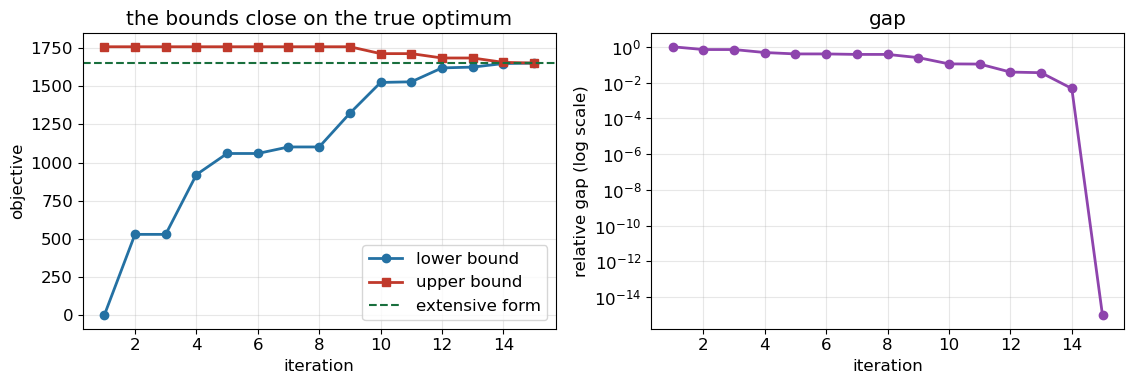

,iter,LB,UB,gap,cuts
0,1,0.000000,1758.173192,1.000000e+00,24
1,2,529.817111,1758.173192,6.986548e-01,24
2,3,529.817111,1758.173192,6.986548e-01,24
3,4,920.817111,1758.173192,4.762648e-01,24
4,5,1059.346628,1758.173192,3.974731e-01,24
5,6,1059.346628,1758.173192,3.974731e-01,24
6,7,1102.176888,1758.173192,3.731124e-01,24
7,8,1102.176888,1758.173192,3.731124e-01,24
8,9,1323.095347,1758.173192,2.474602e-01,24
9,10,1524.509025,1713.225049,1.101525e-01,24


In [13]:
hist = pd.DataFrame(LS["hist"])
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].plot(hist["iter"], hist["LB"], "o-", color="#2471a3", lw=2, label="lower bound")
ax[0].plot(hist["iter"], hist["UB"], "s-", color="#c0392b", lw=2, label="upper bound")
ax[0].axhline(EF_VAL, color="#196f3d", ls="--", lw=1.5, label="extensive form")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("objective")
ax[0].set_title("the bounds close on the true optimum")
ax[0].legend()
ax[1].semilogy(hist["iter"], hist["gap"].clip(lower=1e-16), "o-", color="#8e44ad", lw=2)
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("relative gap (log scale)")
ax[1].set_title("gap")
fig.tight_layout()
plt.show()
hist

The lower bound does **not** rise smoothly. It sits flat for a pass or two, then
jumps — iterations 2→3 and 5→6 and 7→8 move it not at all. That is what a
cutting-plane method looks like on a problem with binaries: the master keeps
proposing plans in a region the cuts have not yet described, and progress arrives
when a cut finally bites somewhere that changes which nodes are open.

The upper bound is worse behaved still: it holds at 1758.17 for eleven
iterations before improving. The gap you would quote at iteration 10 is 11%, and
the answer at that point is already only 3.8% from optimal — the *bound* is
loose, not the incumbent. Stopping early on a Benders gap therefore throws away
a better plan than the gap suggests you have.

## 9. Multicut against single cut

The version above adds one cut per scenario per iteration. The classical L-shaped
method aggregates them into a single cut on one $\theta$.

The trade is the usual one: the aggregated master has far fewer rows, and knows
far less.

> **Predict before you run.** One aggregated cut instead of twenty-four. Does
> that need more iterations, and does it change the answer?

In [14]:
t0 = time.time()
SC1 = lshaped(SCEN, max_iter=200, multicut=False, verbose=False)
T_SC = time.time() - t0

comp = pd.DataFrame([
    dict(variant="multicut", iterations=LS["iters"], subsolves=LS["subsolves"],
         seconds=round(T_LS, 2), value=round(LS["value"], 6),
         master_rows=LS["master"].NumConstrs),
    dict(variant="single cut", iterations=SC1["iters"], subsolves=SC1["subsolves"],
         seconds=round(T_SC, 2), value=round(SC1["value"], 6),
         master_rows=SC1["master"].NumConstrs)])

assert abs(SC1["value"] - EF_VAL) / abs(EF_VAL) < 1e-9, \
    "the single-cut variant found a different optimum"
assert SC1["iters"] > LS["iters"], \
    "aggregating the cuts did not cost iterations; the section has no lesson"
print(f"same optimum to {abs(SC1['value'] - LS['value']) / abs(EF_VAL):.1e}, "
      f"{SC1['iters'] / LS['iters']:.2f}x the iterations")
comp

same optimum to 2.8e-16, 1.47x the iterations


,variant,iterations,subsolves,seconds,value,master_rows
0,multicut,15,360,0.58,1651.194488,324
1,single cut,22,528,0.70,1651.194488,33


**Same optimum, 1.47× the iterations, and 528 subproblem solves against 360.**
Aggregating loses information: twenty-four scenarios that disagree about which
node is short get averaged into one direction, and the master has to discover the
disagreement over more passes.

Note what did *not* happen — the single-cut master is smaller in rows but that
did not make it faster overall, because the cost here is dominated by solving
subproblems, and the single-cut variant solves more of them.

## 10. What decomposition actually buys, measured

Now the claim from the front matter, checked. Solve both at four scenario counts
and time them.

> **Predict before you run.** Write down whether you expect L-shaped to overtake
> the extensive form by n = 200.

### 10.1 Now the streamlined version

Section 5 built the extensive form by hand and section 7 built the loop by hand.
This section needs both at four different scenario counts, so wrapping the tree
and the monolithic model in two short functions is the right trade **now** —
after you have written every line of them out once.

Neither wrapper contains anything new. The check that they reproduce the
hand-built result is the first row of the table below: at n = 24 they must return
the tree and the objective section 5 already produced.

In [15]:
# THE FUNCTION IS THE LESSON: these are the section 4 and section 5 cells with
# `n` made a parameter, wrapped only because section 10 needs them at four
# sizes. Nothing is hidden - compare them line by line with those cells.
def tree(n):
    """Section 4's scenario tree at any size, same seed and same draw order."""
    r_ = random.Random(SEED)
    return [(f"k{k}", 1.0 / n,
             {r: DEMAND_BASE[r] * (LO + (HI - LO) * r_.random()) for r in REGIONS})
            for k in range(n)]


def build_ef(scens):
    """Section 5's monolithic model, unchanged apart from taking the tree."""
    m = gp.Model()
    m.Params.OutputFlag = 0
    m.Params.MIPGap = MIPGAP
    yy = m.addVars(NODES, vtype=GRB.BINARY)
    cc = m.addVars(NODES, lb=0.0, ub=CMAX)
    m.addConstrs((cc[nd] <= CMAX * yy[nd] for nd in NODES))
    m.addConstrs((cc[nd] >= CMIN * yy[nd] for nd in NODES))
    obj = gp.quicksum(FIX[st_] * yy[st_, rg] + UNIT[st_] * cc[st_, rg]
                      for (st_, rg) in NODES)
    for j, scen in enumerate(scens):
        cj, _ = second_stage(m, cc, scen, f"_{j}")
        obj += scen[1] * cj
    m.setObjective(obj, GRB.MINIMIZE)
    return m


# the wrappers must reproduce what the hand-built cells produced
assert max(abs(tree(NK)[k][2][r] - SCEN[k][2][r])
           for k in range(NK) for r in REGIONS) < 1e-15, \
    "tree() does not reproduce section 4's SCEN"
_chk = build_ef(SCEN)
_chk.optimize()
assert abs(_chk.ObjVal - EF_VAL) / abs(EF_VAL) < 1e-9, \
    "build_ef() does not reproduce section 5's extensive form"
print(f"both wrappers reproduce the hand-built versions "
      f"({_chk.ObjVal:.6f} vs {EF_VAL:.6f})")

both wrappers reproduce the hand-built versions (1651.194488 vs 1651.194488)


Now the sweep itself.

In [16]:
FULL_LICENCE = False   # True only if you have an academic or commercial licence

# Four sizes spanning the licence boundary: 99 scenarios fit the restricted
# ~2,000-variable cap and 100 do not, so 100 and 200 are the interesting ones.
SCALE_N = [24, 50, 100, 200]
LICENCE_CAP = 2000

# The size argument needs no solver: the extensive form is 12 first-stage
# variables plus 20 per scenario, exactly. So it is stated at every n. Only the
# TIMING comparison needs the monolithic model actually built, and on the free
# licence the last two would raise rather than run.
EF_VARS = {n: 2 * len(NODES) + 20 * n for n in SCALE_N}
EF_RUNNABLE = [n for n in SCALE_N if FULL_LICENCE or EF_VARS[n] <= LICENCE_CAP]
if not FULL_LICENCE:
    print(f"FULL_LICENCE = False, so the extensive form is solved only at "
          f"n = {EF_RUNNABLE} ({', '.join(str(EF_VARS[n]) for n in EF_RUNNABLE)} "
          f"variables).")
    print(f"At n = {[n for n in SCALE_N if n not in EF_RUNNABLE]} it would need "
          f"{', '.join(str(EF_VARS[n]) for n in SCALE_N if n not in EF_RUNNABLE)}"
          f" variables and the restricted licence would refuse it - which is this")
    print("section's whole point, so the refusal is the result and not a problem.")
    print("Single-cut L-shaped runs at EVERY size below, because it never builds it.\n")

# Why single cut for the sweep, measured rather than asserted. Multicut adds one
# cut PER SCENARIO per iteration, so its master grows in CONSTRAINTS even though
# its variables stay small - and the restricted licence caps constraints too.
n_big = SCALE_N[-1]
try:
    r_mc = lshaped(tree(n_big), max_iter=200, multicut=True, verbose=False)
    m_mc = r_mc["master"]
    m_mc.update()
    print(f"multicut at n = {n_big}: master {m_mc.NumVars} variables, "
          f"{m_mc.NumConstrs} constraints, {r_mc['iters']} iterations - accepted")
    print("(you are on a full licence; on the restricted one this is refused)")
except gp.GurobiError as err:
    # The size argument is arithmetic and needs no solver, exactly like the
    # extensive form's 12 + 20n above: the multicut master holds the same
    # first-stage variables plus one theta per scenario, and gains one cut per
    # scenario per iteration. So it can be stated even when it cannot be solved.
    mc_vars = 2 * len(NODES) + n_big
    print(f"multicut at n = {n_big}: REFUSED - {err}")
    print(f"Its master would be {mc_vars} variables "
          f"({2 * len(NODES)} first-stage + one theta per scenario) and gains "
          f"{n_big} constraints per iteration.")
    print("Its master is small in VARIABLES and large in CONSTRAINTS: one cut per")
    print("scenario per iteration. Escaping a limit on variables is not escaping")
    print("the limit. Single cut adds one cut per iteration and fits at every size.\n")

rows = []
for n in SCALE_N:
    sc_n = tree(n)
    ef_sec = ef_obj = None
    if n in EF_RUNNABLE:
        m_n = build_ef(sc_n)
        t0 = time.time()
        m_n.optimize()
        ef_sec, ef_obj = round(time.time() - t0, 2), m_n.ObjVal
        assert m_n.NumVars == EF_VARS[n], "the variable-count arithmetic is wrong"

    # multicut=False. Multicut adds one cut PER SCENARIO per iteration, so at
    # n = 200 its master reaches ~3,000 constraints - and the restricted licence
    # caps constraints as well as variables. Single cut adds one cut per
    # iteration, 22 in all, and fits at every size.
    t0 = time.time()
    r_n = lshaped(sc_n, max_iter=200, multicut=False, verbose=False)
    t_ls = time.time() - t0

    rows.append(dict(n=n, EF_vars=EF_VARS[n], EF_fits=EF_VARS[n] <= LICENCE_CAP,
                     EF_sec=ef_sec, LS_master_vars=r_n["master"].NumVars,
                     LS_sec=round(t_ls, 2), LS_iters=r_n["iters"],
                     rel=(f"{abs(r_n['value'] - ef_obj) / abs(ef_obj):.1e}"
                          if ef_obj is not None else "-")))
scale = pd.DataFrame(rows)

ran = scale.dropna(subset=["EF_sec"])
assert (ran.LS_sec > ran.EF_sec).all(), (
    "L-shaped came out faster somewhere; this notebook's framing says it does "
    "not, so the prose would need rewriting rather than the assertion relaxing")
assert scale.LS_iters.nunique() == 1, \
    "the iteration count moved with n; section 10's claim depends on it not doing so"
assert (~scale.EF_fits).any(), \
    "every size fits the licence cap, so this section has nothing to demonstrate"
print(f"iterations at every scenario count: {sorted(set(scale.LS_iters))}")
print(f"the extensive form stops fitting {LICENCE_CAP:,} variables between "
      f"n = {scale[scale.EF_fits].n.max()} and n = {scale[~scale.EF_fits].n.min()}")
scale

FULL_LICENCE = False, so the extensive form is solved only at n = [24, 50] (492, 1012 variables).
At n = [100, 200] it would need 2012, 4012 variables and the restricted licence would refuse it - which is this
section's whole point, so the refusal is the result and not a problem.
Single-cut L-shaped runs at EVERY size below, because it never builds it.



multicut at n = 200: REFUSED - Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information
Its master would be 212 variables (12 first-stage + one theta per scenario) and gains 200 constraints per iteration.
Its master is small in VARIABLES and large in CONSTRAINTS: one cut per
scenario per iteration. Escaping a limit on variables is not escaping
the limit. Single cut adds one cut per iteration and fits at every size.



iterations at every scenario count: [22]
the extensive form stops fitting 2,000 variables between n = 50 and n = 100


,n,EF_vars,EF_fits,EF_sec,LS_master_vars,LS_sec,LS_iters,rel
0,24,492,True,0.01,13,0.67,22,1.4e-16
1,50,1012,True,0.03,13,1.27,22,7.0e-16
2,100,2012,False,NaN,13,2.41,22,-
3,200,4012,False,NaN,13,4.80,22,-


**The extensive form wins on time wherever it can be built at all, and the
assertion above requires that** — if it ever stopped being true on your machine,
this notebook's framing would be wrong and the prose would need rewriting, not
the assertion relaxing. The *ratio* is deliberately not quoted: it moved between
two runs on the same laptop while writing this, which is exactly why the
assertion tests the ordering and not a number.

**And notice where the timing column stops.** On the default restricted licence
there is no `EF_sec` for n = 100 or n = 200, because those models are 2,012 and
4,012 variables and the licence will not solve them. That blank is the finding.
The `EF_vars` column is still filled in at every size, because it is arithmetic
— 12 first-stage variables plus 20 per scenario — and needs no solver to state.
L-shaped has a number in every row.

What changes is the model you have to build. At n = 200 the extensive form needs
4,012 variables; the single-cut master needs **13** and each subproblem 20. On the
restricted licence the monolithic model is simply unavailable past n ≈ 99, and the
decomposition is unaffected because it never holds more than one scenario at a
time.

**With one caveat that is easy to state wrongly, and this notebook did.** The
sweep above runs `multicut=False`. Multicut's master is only 212 variables at
n = 200 — comfortably inside the cap — but it adds **one cut per scenario per
iteration**, so 15 iterations at n = 200 is roughly 3,000 constraints, and the
restricted licence caps constraints too. Measured: multicut solves at n = 24, 50
and 100 and is refused at 200; single cut, one cut per iteration, fits at every
size. *Escaping a limit on variables is not escaping the limit.*

And the striking one: **the iteration count is 22 at every scenario count
tested** — 24, 50, 100 and 200. The number of cuts needed is a property of the
first-stage geometry, six nodes with open/close decisions, not of how many
scenarios there are. That is the property that makes the method scale, and it is
the assertion in the cell above.

## 11. Are the duals actually saying anything?

A cut built from an all-zero dual vector is a flat line: it says the recourse
cost is at least some constant, regardless of capacity. Such a cut is valid and
useless. Worth checking how often the duals are informative.

In [17]:
rows = []
for label, cap in (("all-zero capacity", {n: 0.0 for n in NODES}),
                   ("the optimal plan", LS["plan"])):
    nz = tot = 0
    for scen in SCEN:
        _, beta = recourse(cap, scen)
        nz += sum(1 for n in NODES if abs(beta[n]) > 1e-9)
        tot += len(NODES)
    rows.append(dict(evaluated_at=label, nonzero_duals=nz, total=tot,
                     pct_binding=round(100 * nz / tot, 1)))
duals = pd.DataFrame(rows)
assert (duals.nonzero_duals > 0).all(), \
    "no dual was ever nonzero, so every cut would be a flat line"
print("a nonzero dual means that node's capacity row is binding in that scenario,")
print("so the cut it generates actually slopes.")
duals

a nonzero dual means that node's capacity row is binding in that scenario,
so the cut it generates actually slopes.


,evaluated_at,nonzero_duals,total,pct_binding
0,all-zero capacity,48,144,33.3
1,the optimal plan,74,144,51.4


At the optimal plan **51.4% of the capacity rows bind**, against 33.3% at zero
capacity. That is the right direction: at zero capacity most nodes are so far
from useful that the binding constraint is demand, not capacity, and the cut
carries information about only a third of the nodes.

This is the diagnostic to reach for when a Benders implementation stalls. A loop
that adds cuts and never moves the bound is usually generating cuts with no
slope, and this counts them.

## 12. The agreement assertion

Everything above was built by hand; `src/lithium/twostage.py` holds the same
models as functions. The same model exists twice, deliberately — and deliberate
duplication with nothing comparing the copies is how a bug gets fixed in three
places out of four.

This compares the scenario tree, the extensive form, the recourse values **and
their duals**, both cut variants, and the full convergence history. The duals
matter: an implementation could agree on every objective and still build its cuts
from the wrong sign, and only a disagreement in $\beta$ would show it.

In [18]:
from lithium import TwoStageInstance, build_twostage_structure
from lithium import twostage as T2

nb_inst = TwoStageInstance(
    stages=STAGES, regions=REGIONS, fix=FIX, unit=UNIT, opc=OPC, eta=ETA,
    demand_base=DEMAND_BASE, region_cost=REGION_COST)
nb_st = build_twostage_structure(nb_inst, cmin=CMIN, cmax=CMAX, pen=PEN,
                                 tau_own=TAU_OWN, tau_cross=TAU_CROSS)

pkg_scen = T2.demand_scenarios(nb_st, n=NK, seed=SEED, lo=LO, hi=HI)
worst = max(abs(pkg_scen[k][2][r] - SCEN[k][2][r])
            for k in range(NK) for r in REGIONS)
print(f"{'scenario tree':30s} max abs diff {worst:.2e}")
assert worst < 1e-12, "the notebook and the package disagree on the tree"

pkg_ef = T2.extensive_form(nb_st, pkg_scen, mipgap=MIPGAP)
pkg_ef.optimize()
rel = abs(pkg_ef.ObjVal - EF_VAL) / abs(EF_VAL)
print(f"{'extensive form':30s} notebook {EF_VAL:12.6f}  "
      f"package {pkg_ef.ObjVal:12.6f}  rel {rel:.1e}")
assert rel < 1e-9, f"extensive forms disagree by {rel:.2e}"

scenario tree                  max abs diff 0.00e+00
extensive form                 notebook  1651.194488  package  1651.194488  rel 0.0e+00


The objectives agreeing is necessary and not sufficient. Two implementations can
report the same optimum and still build their cuts differently — from duals of
the opposite sign, say, or from a subproblem solved at a different point. So the
rest of the comparison goes after the machinery rather than the answer: the
recourse values **and their duals** at eight (scenario, plan) pairs, both cut
variants, and the whole convergence path.

In [19]:
zero = {n: 0.0 for n in NODES}
wv = wb = 0.0
for k in (0, 7, 13, 23):
    for cap in (zero, LS["plan"]):
        qa, ba = recourse(cap, SCEN[k])
        qb, bb = T2.recourse(nb_st, pkg_scen[k], cap)
        wv = max(wv, abs(qa - qb) / max(abs(qb), 1e-12))
        wb = max(wb, max(abs(ba[n] - bb[n]) for n in NODES))
print(f"{'recourse values (8 cases)':30s} max rel diff {wv:.2e}")
print(f"{'capacity duals (8 cases)':30s} max abs diff {wb:.2e}")
assert wv < 1e-9 and wb < 1e-9, "the recourse LP or its duals disagree"

for multi, label in ((True, "multicut"), (False, "single cut")):
    a = LS if multi else SC1
    b = T2.lshaped(nb_st, pkg_scen, multicut=multi, max_iter=200, mipgap=MIPGAP)
    rel = abs(a["value"] - b["value"]) / abs(b["value"])
    print(f"{label + ' value':30s} notebook {a['value']:12.6f}  "
          f"package {b['value']:12.6f}  rel {rel:.1e}")
    assert rel < 1e-9, f"{label} disagrees by {rel:.2e}"
    assert a["iters"] == b["iters"], (
        f"{label}: {a['iters']} iterations here against {b['iters']} in the "
        f"package - the loops are not the same loop")
    wh = max(abs(a["hist"][i]["LB"] - b["hist"][i]["LB"])
             for i in range(len(a["hist"])))
    print(f"{'  its convergence history':30s} max abs diff {wh:.2e}")
    assert wh < 1e-6, f"{label} converges along a different path"

print("\nnotebook and package agree on the tree, the extensive form, the")
print("recourse values, the DUALS, both cut variants, and the whole path there")

recourse values (8 cases)      max rel diff 0.00e+00
capacity duals (8 cases)       max abs diff 0.00e+00


multicut value                 notebook  1651.194488  package  1651.194488  rel 0.0e+00
  its convergence history      max abs diff 0.00e+00


single cut value               notebook  1651.194488  package  1651.194488  rel 0.0e+00
  its convergence history      max abs diff 0.00e+00

notebook and package agree on the tree, the extensive form, the
recourse values, the DUALS, both cut variants, and the whole path there


## 13. Summary

| Question | Answer |
|---|---|
| Does L-shaped reproduce the extensive form? | **Yes**, to 1e-9, and the bounds bracket the optimum |
| Is it faster? | **No** — it loses at every size tested, and the assertion in section 10 says so |
| Then what does it buy? | The extensive form needs 4,012 variables at n=200; the single-cut master needs 13 |
| How many iterations? | **22** single cut, at n = 24, 50, 100 and 200 alike; 15 for multicut where it fits |
| Multicut or single cut? | Same optimum; single cut takes 1.47× the iterations and 528 subsolves against 360 — but multicut's per-scenario cuts exceed the restricted licence's constraint cap at n = 200, and single cut does not |
| Is the Benders gap a good stopping rule? | **Careful.** At iteration 10 the gap says 11% and the incumbent is 3.8% off |
| Are the cuts informative? | 51.4% of capacity rows bind at the optimum, 33.3% at zero capacity |

### Formulation lessons

- **The cut is the dual.** $Q_k$ convex in the right-hand side is what makes a
  subgradient a valid underestimate everywhere. Lose the LP and you lose the cut.
- **The master is a relaxation**, so its objective is always a lower bound —
  which is what gives this method a certificate that progressive hedging has not.
- **A loose bound is not a bad incumbent.** Benders' gap closes from the bound
  side; stopping early discards a better plan than the gap admits.
- **`lb=0` on $\theta$ is a modelling decision, not a formality.** It is valid
  only because every second-stage cost is non-negative. State that, because on a
  model with revenues it is wrong and the first master is unbounded.
- **Decomposition is a size argument, not a speed argument** — at least until the
  monolithic model stops fitting in memory or in a licence.
- **Do not put a wall time in prose.** Assert the ordering you rely on and print
  the numbers from the reader's own run.

### Things to try

- `SCEN` with `NK = 200` at the top, then *Run all* — the extensive form leaves
  the restricted licence behind and the L-shaped loop does not notice
- `multicut=False` in section 7's call, and watch section 8's assertion still pass
- `PEN = 300` — make shortfall ruinous and see whether the plan still concentrates
- `TAU_CROSS = 0.35` — nearly free transport, so siting stops mattering
- Set $\theta$'s `lb=-GRB.INFINITY` and watch the first master go unbounded

### Where this goes next

**Part 2c** keeps this instance and changes the question from *how do I solve it*
to *what am I solving for* — expectation, CVaR, or the worst case.